### Create Gaussian Process around dataset

In [1]:
from agent.components.RASK import get_dependent_variable_mapping
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType

# TODO: Build a training/test split, but keep the order still
s_type = ServiceType.QR
df = pd.read_csv("../statics/metrics_RASK_180_0.csv")
# 2. Initialize and train

### Gaussian Process gives you µ,s for an arbitrary point

In [2]:

# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0})
# gp.predict(s_type, "max_tp", {'data_quality': 10000, 'cores': 600.0})
# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0, 'model_size': 2.0})


### Test if the global optimizer converges to a nice result

In [3]:
from agent.components.GaussianProcess import get_empirical_variable_bounds
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos_default = slo_lib.get_slo_for_client("experiment-1", "default")
slos_high_perf = slo_lib.get_slo_for_client("experiment-1", "high_perf")
slos_low_cost = slo_lib.get_slo_for_client("experiment-1", "low_cost")
slos_high_quality = slo_lib.get_slo_for_client("experiment-1", "high_quality")



### Test how much the epsilon should be moved each iteration

In [4]:
# from agent.components.commons import ServiceVar
# from agent.components.Optimizer import local_obj
# from agent.components.GaussianProcess import get_empirical_variable_bounds
# import numpy as np
#
# # Convert to a numpy array so we can do math on the whole vector
# x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))
#
# simple_param_bounds = get_empirical_variable_bounds(gp_service.training_data)[s_type]
# del simple_param_bounds[ServiceVar.PERFORMANCE]
# simple_param_bounds = list(simple_param_bounds.values())
#
# for e in [1e-5, 1e-3, 1e-2, 5e-2]:
#     # val_start uses the original center
#     val_start = local_obj(x_norm, s_type, slos_default, gp_service, simple_param_bounds)
#
#     # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
#     val_nudge = local_obj(x_norm + e, s_type, slos_default, gp_service, simple_param_bounds)
#
#     diff = abs(val_start - val_nudge)
#     print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

### Create versatile map of different solutions

In [5]:
from agent.components.commons import ServiceVar
from typing import Dict
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites


def extract_pfo_for_SLOs(gp, slos: Dict[ServiceVar, float], slo_type: str):
    v_me = VersatileMapElites(s_type, bins=10)

    #  I'm getting the black cells because they are not explored.
    #  What I can do is force all cells to be explored at least once,
    #  or just run gradient descent for each cell multiple (like 5) times.
    v_me.run_search(slos, gp, simple_param_bounds, iterations=5000)
    visualize_ndarray(v_me.fitness_table, gp.s_type.value + "_" + slo_type)

    # Get n solutions that are high-performing but far apart
    diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)
    print("\n".join(f"Versatile Candidate: {x}" for x in diverse_set))

# extract_pfo_for_SLOs(gp_service, slos_default, "default")

In [6]:
# extract_pfo_for_SLOs(gp_service, slos_high_perf, "high_perf")

In [7]:
# extract_pfo_for_SLOs(gp_service, slos_low_cost, "low_cost")

In [8]:
# extract_pfo_for_SLOs(gp_service, slos_high_quality, "high_quality")

In [9]:

gp_list = []
lml_history = []

data_splits = 10

for i in range(data_splits):
    data_ratio = (i + 1) / data_splits

    # Initialize and train GP model
    _gp = GASK(s_type, show_figures=False)
    _gp.init_model(df, data_density=data_ratio)
    gp_list.append(_gp)

    lml = _gp.get_model_lml(s_type, "max_tp")
    lml_history.append(lml)
    print(f"Ratio {data_ratio}: LML = {lml:.2f}")


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 276 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp


Ratio 0.1: LML = -23.19


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 268 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp


Ratio 0.2: LML = -29.81


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 239 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp


...

Ratio 0.8: LML = -96.09


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 930 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp


Ratio 0.9: LML = -99.65


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 1404 ms to execute


Ratio 1.0: LML = -102.57


In [10]:
from agent.components.Optimizer import run_optimizer_multi

slo_set = slos_high_perf
solution_history = []

for i in range(data_splits):
    data_ratio = (i + 1) / data_splits

    gp = gp_list[i]
    empirical_var_bounds = get_empirical_variable_bounds(gp.training_data)[s_type]

    # Run optimizer to find the best configuration
    solutions = run_optimizer_multi(s_type, slo_set, gp, empirical_var_bounds, runs=10)
    fitness, config = max(solutions, key=lambda x: x[0])

    # Predict performance (mu, sigma) for the chosen configuration
    x_state = {ServiceVar.COST: config[0], ServiceVar.QUALITY: config[1]}
    x_state = x_state | ({ServiceVar.MODEL: config[2]} if s_type == ServiceType.CV else {})
    mu, sigma = gp.predict(s_type, "max_tp", x_state)

    # Store everything needed for the next block
    # We include empirical_var_bounds here as it changes per iteration
    solution_history.append({
        'fitness': fitness,
        'config': config,
        'dist': (mu, sigma),
        'x_state': x_state,
        'bounds': empirical_var_bounds
    })

In [11]:
from agent.components.SLORegistry_v2 import calculate_weighted_SLO_F
import numpy as np

slo_means = []
slo_stds = []
num_samples = 500

for entry in solution_history:
    mu, sigma = entry['dist']
    x_state = entry['x_state']
    bounds = entry['bounds']

    # 1. Sample performance points from the normal distribution
    samples = np.random.normal(mu, sigma, num_samples)

    # 2. Evaluate SLO fulfillment for every sample
    slo_results = []
    for s in samples:
        sample_tp = {ServiceVar.PERFORMANCE: s}

        val = calculate_weighted_SLO_F(
            x_state | sample_tp,
            slo_set,
            bounds
        )
        slo_results.append(val)

    # 3. Aggregate statistics
    slo_means.append(np.mean(slo_results))
    slo_stds.append(np.std(slo_results))

# Prepare data for plotting
slo_means = np.array(slo_means)
slo_stds = np.array(slo_stds)
lml_history = np.array(lml_history)

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_107545/2678004413.py:24: SyntaxWarning: invalid escape sequence '\p'
  label='$\pm 1$ Std Dev'


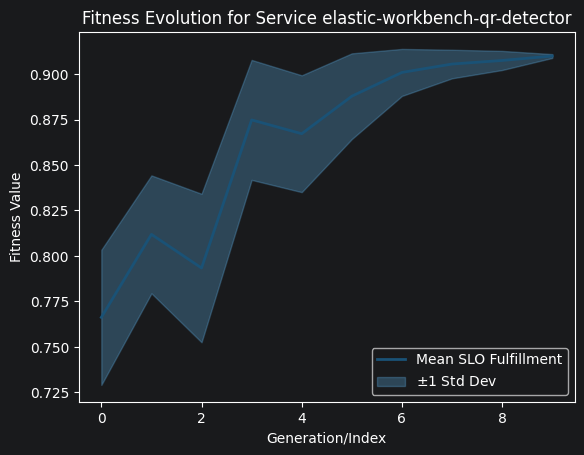

In [12]:

import matplotlib.pyplot as plt

# fitness_list = np.array([f for f, c, g in solution_history])
#
# process_list = [g for f, c, g in solution_history]
# uncertainty = np.array([(sd / 300) for m, sd in process_list])

under_line = slo_means - slo_stds
over_line = slo_means + slo_stds

hacked_certainty = (3.0 + (lml_history / 50))
data_normalizer = [i + 1 / 10 for i in range(data_splits)]

# plt.plot(hacked_certainty / data_normalizer, label='Model Likelihood', color='red', linewidth=2)

plt.plot(slo_means, label='Mean SLO Fulfillment', color='#1A5276', linewidth=2)

plt.fill_between(
    range(len(slo_means)),
    slo_means - slo_stds,
    slo_means + slo_stds,
    color='#5DADE2',
    alpha=0.3,
    label='$\pm 1$ Std Dev'
)

plt.xlabel("Generation/Index")
plt.ylabel("Fitness Value")
plt.title(f"Fitness Evolution for Service {s_type.value}")
plt.legend()
# plt.ylim([-0.5, 1.0])
plt.savefig(f"../figures/evolution_{s_type.value}.jpg")
plt.show()

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


GP 1 (Density 0.1) | SLO RMSE: 0.3383
GP 2 (Density 0.2) | SLO RMSE: 0.3596
GP 3 (Density 0.3) | SLO RMSE: 0.4147
GP 4 (Density 0.4) | SLO RMSE: 0.5118
GP 5 (Density 0.5) | SLO RMSE: 0.5048
GP 6 (Density 0.6) | SLO RMSE: 0.5112
GP 7 (Density 0.7) | SLO RMSE: 0.5140
GP 8 (Density 0.8) | SLO RMSE: 0.5144
GP 9 (Density 0.9) | SLO RMSE: 0.5147
GP 10 (Density 1.0) | SLO RMSE: 0.5150


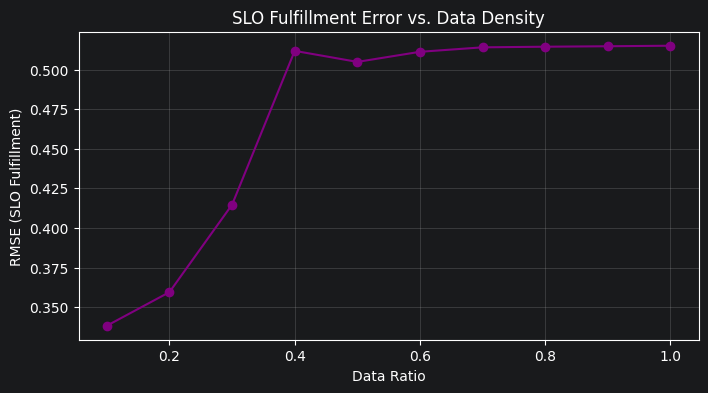

In [14]:
from sklearn.metrics import mean_squared_error
from agent.components import RASK

# 1. Prepare static validation set (unseen data)
# We sample from the full df to have a consistent benchmark
test_df = RASK.preprocess_data(df).sample(frac=0.2, random_state=35)
dep_vars = get_dependent_variable_mapping(s_type)["max_tp"]
X_test = test_df[dep_vars].values
y_actual_perf = test_df["max_tp"].values

# 2. Calculate "Ground Truth" SLO Fulfillment once
# We use the empirical bounds from the most complete model (the last one)
final_bounds = get_empirical_variable_bounds(gp_list[-1].training_data)[s_type]
actual_slo_f = []

for i in range(len(test_df)):
    row = test_df.iloc[i]
    x_state = {ServiceVar.COST: row.get('cores'), ServiceVar.QUALITY: row.get('data_quality')}
    if s_type == ServiceType.CV: x_state[ServiceVar.MODEL] = row.get('model_size')

    val = calculate_weighted_SLO_F(x_state | {ServiceVar.PERFORMANCE: y_actual_perf[i]}, slo_set, final_bounds)
    actual_slo_f.append(val)

# 3. Loop through gp_list to calculate Predicted SLO Fulfillment RMSE
slo_rmse_history = []

for idx, val_gp in enumerate(gp_list):
    pred_slo_f = []
    y_pred_perf = val_gp.models[s_type]["max_tp"].predict(X_test)

    for i in range(len(test_df)):
        row = test_df.iloc[i]
        x_state = {ServiceVar.COST: row.get('cores'), ServiceVar.QUALITY: row.get('data_quality')}
        if s_type == ServiceType.CV: x_state[ServiceVar.MODEL] = row.get('model_size')

        # Calculate fulfillment based on GP prediction
        val = calculate_weighted_SLO_F(x_state | {ServiceVar.PERFORMANCE: y_pred_perf[i]}, slo_set, final_bounds)
        pred_slo_f.append(val)

    # Compute RMSE for this specific GP
    rmse = np.sqrt(mean_squared_error(actual_slo_f, pred_slo_f))
    slo_rmse_history.append(rmse)

    print(f"GP {idx+1} (Density {(idx+1)/10:.1f}) | SLO RMSE: {rmse:.4f}")

# --- Plot the learning curve ---
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(0.1, 1.0, len(slo_rmse_history)), slo_rmse_history, marker='o', color='purple')
plt.title("SLO Fulfillment Error vs. Data Density")
plt.xlabel("Data Ratio")
plt.ylabel("RMSE (SLO Fulfillment)")
plt.grid(True, alpha=0.3)
plt.show()